In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load insurance dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

# Show first rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Information
print(df.info())

# Summary
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000

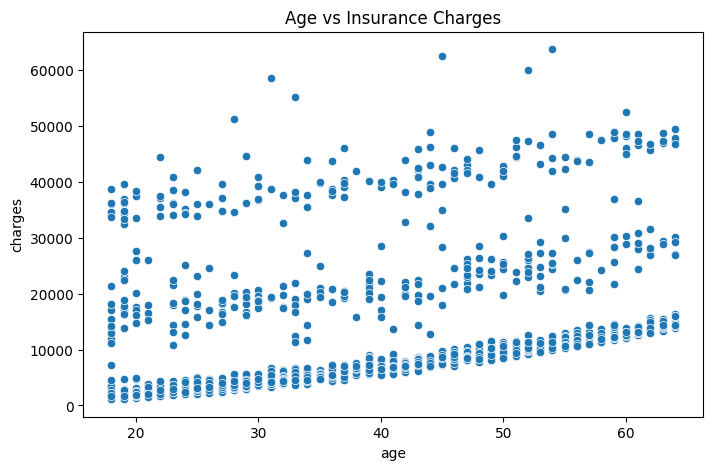

In [2]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='charges',
    data=df
)

plt.title("Age vs Insurance Charges")
plt.show()

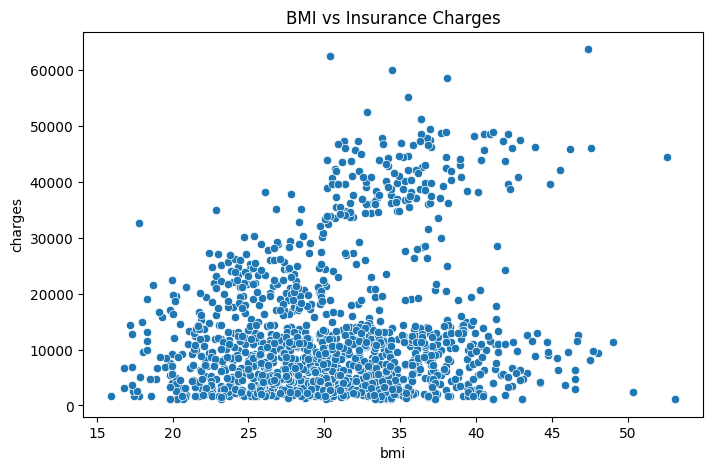

In [3]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bmi',
    y='charges',
    data=df
)

plt.title("BMI vs Insurance Charges")
plt.show()

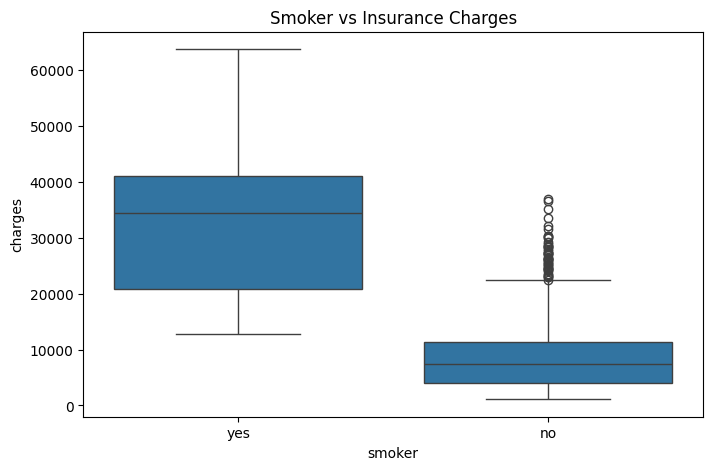

In [4]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title("Smoker vs Insurance Charges")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Convert text columns to numbers
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# Features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4186.508898366433
RMSE: 5799.587091438356


Conclusion:
Insurance data was analyzed successfully. Age, BMI, and smoking status affected insurance charges. Linear Regression was used to predict claim amounts and model performance was evaluated using MAE and RMSE